---

# First EDA on Dummy Data

---

---

## Setup

---

In [276]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import nltk

In [277]:
# Download the quietly
nltk.download('omw-1.4', quiet=True)

# Download Open Multilingual WordNet database 
# ( multilingual dictionary database for lemmatization and word relations)

nltk.download('omw-1.4', quiet=True)

True

In [278]:
# Suppress warning messages to keep the output clean
import warnings
warnings.filterwarnings('ignore')

# Set the background style of the plots to a white grid
sns.set_style('whitegrid')

# Set the default size for all plots (width: 17, height: 7)
plt.rcParams['figure.figsize'] = (17,7)

---

## Loading Data & First Cleaning

---

In [279]:
# Read in data (example for CSV)
data = pd.read_csv('data/synthetic_employee_survey_500_same_structure.csv')

# First preview (First 5 rows)
display(data.head())

# Check structure and data types (null values, column names)
data.info()

,ID,Startzeit,Fertigstellungszeit,E-Mail,Name,Language,Ich arbeite bei ...,[Organization]: Ich arbeite im Bereich ...,team_effizienz,staerken_nutzen,...,rahmenbedingungen_change,arbeitgeber_empfehlung,arbeitsfreude,teamstimmung,work_life_balance,ueberlastung,Möchtest Du noch etwas mit den Kolleg*innen teilen?,IterationID,RunID,AbteilungsID
0,1,2026-01-02 13:43:00,2026-01-02 13:57:00,anonymous,anonymous,Deutsch,[Organization],IN-AL (Innovationsfeld Alpha),Stimme voll und ganz zu,Teils/Teils,...,Stimme eher zu,Teils/Teils,Stimme voll und ganz zu,Stimme voll und ganz zu,Stimme voll und ganz zu,Stimme eher zu,"Ehrlich gesagt: Ich weiß genau, woran ich arbe...",26_1,1,90039353
1,2,2026-01-04 15:18:00,2026-01-04 15:31:00,anonymous,anonymous,Deutsch,[Organization],IN-AL (Innovationsfeld Alpha),Stimme eher zu,Teils/Teils,...,Stimme eher zu,Stimme eher zu,Stimme eher zu,Kann ich nicht beurteilen,Teils/Teils,Stimme eher nicht zu,Bringt ja eh nichts. Wissen hängt bei uns an e...,26_1,1,98837590
2,3,2026-01-03 15:23:00,2026-01-03 15:30:00,anonymous,anonymous,Deutsch,[Organization],KE-EP (Kernbereich Epsilon),Stimme eher zu,Teils/Teils,...,Stimme eher zu,Teils/Teils,Stimme eher zu,Stimme eher nicht zu,Teils/Teils,Stimme voll und ganz zu,"Ich finde die Richtung richtig, auch wenn der ...",26_1,1,92276360
3,4,2026-01-01 13:00:00,2026-01-01 13:06:00,anonymous,anonymous,Deutsch,[Organization],IN-AL (Innovationsfeld Alpha),Stimme voll und ganz zu,Stimme eher zu,...,Stimme voll und ganz zu,Stimme eher zu,Stimme eher zu,Stimme eher zu,Stimme voll und ganz zu,Teils/Teils,"Ehrlich, ich kann nicht mehr. Konflikte werden...",26_1,1,94657693
4,5,2026-01-03 08:42:00,2026-01-03 09:00:00,anonymous,anonymous,Deutsch,[Organization],ZU-BE (Zukunftssegment Beta),Stimme eher zu,Stimme eher nicht zu,...,Stimme voll und ganz zu,Teils/Teils,Stimme voll und ganz zu,Stimme voll und ganz zu,Stimme voll und ganz zu,Teils/Teils,Aus meiner Sicht: Die neue Struktur ergibt für...,26_1,1,90786667


<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 66 columns):
 #   Column                                               Non-Null Count  Dtype
---  ------                                               --------------  -----
 0   ID                                                   500 non-null    int64
 1   Startzeit                                            500 non-null    str  
 2   Fertigstellungszeit                                  500 non-null    str  
 3   E-Mail                                               500 non-null    str  
 4   Name                                                 500 non-null    str  
 5   Language                                             500 non-null    str  
 6   Ich arbeite bei ...                                  500 non-null    str  
 7   [Organization]: Ich arbeite im Bereich ...           500 non-null    str  
 8   team_effizienz                                       500 non-null    str  
 9   staerken_nutzen      

In [280]:
# Remove useless columns

data = data.drop(['ID','E-Mail', 'Name', 'Language'], axis=1)

In [281]:
# Rename Columns

# Clean column names:
# - Removes the invisible character \u200b
# - Replaces all whitespaces (tabs, line breaks, non-breaking spaces \xa0) with a standard space
# - Removes leading and trailing whitespace (strip)
data.columns = (
    data.columns
    .str.replace(r'\u200b', '', regex=True)
    .str.replace(r'\s+', ' ', regex=True)
    .str.strip()
)

# Column Mapping dictionary
column_mapping = {
    "Startzeit": "start",
    "Fertigstellungszeit": "ende",
    "Ich arbeite bei ...": "organisation",
    "[Organization]: Ich arbeite im Bereich ...": "bereich",
    "Möchtest Du noch etwas mit den Kolleg*innen teilen?": "freitext_kommentar",
    "IterationID": "iteration_id",
    "RunID": "run_id",
    "AbteilungsID": "abteilungs_id"
}

# Rename columns
data = data.rename(columns=column_mapping)
data.head(3)

,start,ende,organisation,bereich,team_effizienz,staerken_nutzen,zusammenarbeit_team,psychologische_sicherheit,info_fuehrung_veraenderung,produktgestaltung_aktiv,...,rahmenbedingungen_change,arbeitgeber_empfehlung,arbeitsfreude,teamstimmung,work_life_balance,ueberlastung,freitext_kommentar,iteration_id,run_id,abteilungs_id
0,2026-01-02 13:43:00,2026-01-02 13:57:00,[Organization],IN-AL (Innovationsfeld Alpha),Stimme voll und ganz zu,Teils/Teils,Stimme voll und ganz zu,Stimme voll und ganz zu,Stimme voll und ganz zu,Stimme eher zu,...,Stimme eher zu,Teils/Teils,Stimme voll und ganz zu,Stimme voll und ganz zu,Stimme voll und ganz zu,Stimme eher zu,"Ehrlich gesagt: Ich weiß genau, woran ich arbe...",26_1,1,90039353
1,2026-01-04 15:18:00,2026-01-04 15:31:00,[Organization],IN-AL (Innovationsfeld Alpha),Stimme eher zu,Teils/Teils,Stimme voll und ganz zu,Stimme voll und ganz zu,Stimme eher nicht zu,Stimme gar nicht zu,...,Stimme eher zu,Stimme eher zu,Stimme eher zu,Kann ich nicht beurteilen,Teils/Teils,Stimme eher nicht zu,Bringt ja eh nichts. Wissen hängt bei uns an e...,26_1,1,98837590
2,2026-01-03 15:23:00,2026-01-03 15:30:00,[Organization],KE-EP (Kernbereich Epsilon),Stimme eher zu,Teils/Teils,Stimme eher zu,Stimme eher zu,Teils/Teils,Teils/Teils,...,Stimme eher zu,Teils/Teils,Stimme eher zu,Stimme eher nicht zu,Teils/Teils,Stimme voll und ganz zu,"Ich finde die Richtung richtig, auch wenn der ...",26_1,1,92276360


---

## Data Structure 

---

In [282]:
# Take a first look at the remaining data
display(data.head(3))

,start,ende,organisation,bereich,team_effizienz,staerken_nutzen,zusammenarbeit_team,psychologische_sicherheit,info_fuehrung_veraenderung,produktgestaltung_aktiv,...,rahmenbedingungen_change,arbeitgeber_empfehlung,arbeitsfreude,teamstimmung,work_life_balance,ueberlastung,freitext_kommentar,iteration_id,run_id,abteilungs_id
0,2026-01-02 13:43:00,2026-01-02 13:57:00,[Organization],IN-AL (Innovationsfeld Alpha),Stimme voll und ganz zu,Teils/Teils,Stimme voll und ganz zu,Stimme voll und ganz zu,Stimme voll und ganz zu,Stimme eher zu,...,Stimme eher zu,Teils/Teils,Stimme voll und ganz zu,Stimme voll und ganz zu,Stimme voll und ganz zu,Stimme eher zu,"Ehrlich gesagt: Ich weiß genau, woran ich arbe...",26_1,1,90039353
1,2026-01-04 15:18:00,2026-01-04 15:31:00,[Organization],IN-AL (Innovationsfeld Alpha),Stimme eher zu,Teils/Teils,Stimme voll und ganz zu,Stimme voll und ganz zu,Stimme eher nicht zu,Stimme gar nicht zu,...,Stimme eher zu,Stimme eher zu,Stimme eher zu,Kann ich nicht beurteilen,Teils/Teils,Stimme eher nicht zu,Bringt ja eh nichts. Wissen hängt bei uns an e...,26_1,1,98837590
2,2026-01-03 15:23:00,2026-01-03 15:30:00,[Organization],KE-EP (Kernbereich Epsilon),Stimme eher zu,Teils/Teils,Stimme eher zu,Stimme eher zu,Teils/Teils,Teils/Teils,...,Stimme eher zu,Teils/Teils,Stimme eher zu,Stimme eher nicht zu,Teils/Teils,Stimme voll und ganz zu,"Ich finde die Richtung richtig, auch wenn der ...",26_1,1,92276360


In [283]:
data.shape

(500, 62)

In [284]:
# Show column names and Datatypes
print(data.info())

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 62 columns):
 #   Column                              Non-Null Count  Dtype
---  ------                              --------------  -----
 0   start                               500 non-null    str  
 1   ende                                500 non-null    str  
 2   organisation                        500 non-null    str  
 3   bereich                             500 non-null    str  
 4   team_effizienz                      500 non-null    str  
 5   staerken_nutzen                     500 non-null    str  
 6   zusammenarbeit_team                 500 non-null    str  
 7   psychologische_sicherheit           500 non-null    str  
 8   info_fuehrung_veraenderung          500 non-null    str  
 9   produktgestaltung_aktiv             500 non-null    str  
 10  weiterentwicklung_foerderung        500 non-null    str  
 11  fehlerkultur_keine_vorwuerfe        500 non-null    str  
 12  gestaltungsspielrau

In [285]:
# Statistical overview for numerical columns (Likert values)
display(data.describe())

,run_id,abteilungs_id
count,500.000000,5.000000e+02
mean,2.500000,9.492927e+07
std,1.119154,2.864879e+06
min,1.000000,9.001439e+07
25%,1.750000,9.253794e+07
50%,2.500000,9.485913e+07
75%,3.250000,9.732956e+07
max,4.000000,9.993826e+07


In [286]:
# Do we have missing values in the key columns?
print(data[['start', 'bereich', 'freitext_kommentar']].isnull().sum())

start                  0
bereich                0
freitext_kommentar    18
dtype: int64


In [287]:
# How many different areas and organizations are there?
print(data['bereich'].value_counts(dropna=False))

bereich
IN-AL (Innovationsfeld Alpha)        114
TR-DE (Transformationsfeld Delta)    108
ZU-BE (Zukunftssegment Beta)         106
KE-EP (Kernbereich Epsilon)           90
FO-GA (Fokusbereich Gamma)            82
Name: count, dtype: int64


...

### 🎯 Key Data Insights

| Icon | Metric | Details |
| :--- | :--- | :--- |
| 📊 | **Dataset size** | 500 responses, 62 columns after initial cleaning |
| ✅ | **Completeness** | All structural columns (`start`, `bereich`, `organisation`) are complete. Only `freitext_kommentar` has 18 missing values (3.6%) |
| 🗂️ | **Bereiche** | 5 different bereiche (IN-AL, TR-DE, ZU-BE, KE-EP, FO-GA) with a relatively balanced distribution (82–114 responses per bereich) |
| 📝 | **Likert scales** | All 54 Likert items are stored as strings with response categories such as "Stimme voll und ganz zu", "Stimme eher zu", "Teils/Teils", "Stimme eher nicht zu", "Stimme gar nicht zu", "Kann ich nicht beurteilen" |

...

---

## Numeric Coding for Likert Values (Mapping)

---

In [288]:
scale = data["team_effizienz"].unique()
print(scale)

<StringArray>
[  'Stimme voll und ganz zu',            'Stimme eher zu',
               'Teils/Teils',       'Stimme gar nicht zu',
      'Stimme eher nicht zu', 'Kann ich nicht beurteilen']
Length: 6, dtype: str


In [289]:
# Find out Number of Likert Columns

# List with index and column names
column_list = list(enumerate(data.columns))
print(column_list)

[(0, 'start'), (1, 'ende'), (2, 'organisation'), (3, 'bereich'), (4, 'team_effizienz'), (5, 'staerken_nutzen'), (6, 'zusammenarbeit_team'), (7, 'psychologische_sicherheit'), (8, 'info_fuehrung_veraenderung'), (9, 'produktgestaltung_aktiv'), (10, 'weiterentwicklung_foerderung'), (11, 'fehlerkultur_keine_vorwuerfe'), (12, 'gestaltungsspielraum'), (13, 'kundenfokus'), (14, 'businessentscheidungen_richtung'), (15, 'ehrlichkeit_fuehrung'), (16, 'anforderung_faehigkeit_match'), (17, 'feedback_nutzen'), (18, 'eigenverantwortung_entscheidungen'), (19, 'neues_lernen'), (20, 'beitrag_kundennutzen'), (21, 'erwartungsklarheit'), (22, 'einbeziehung_fuehrung'), (23, 'anspruchsvolle_aufgaben'), (24, 'fehlerkultur_massnahmen'), (25, 'veraenderung_nachvollziehbar'), (26, 'prozessverbesserung_kontinuierlich'), (27, 'einfluss_arbeitsmenge'), (28, 'strategie_einfluss'), (29, 'entscheidungsgeschwindigkeit'), (30, 'prozesse_hinterfragen'), (31, 'hilfe_bitten'), (32, 'lob_anerkennung'), (33, 'klare_ziele'), 

In [290]:
# Dein Mapping
likert_mapping = {
    "Stimme gar nicht zu": 1,
    "Stimme eher nicht zu": 2,
    "Teils/Teils": 3,
    "Stimme eher zu": 4,
    "Stimme voll und ganz zu": 5,
    "Kann ich nicht beurteilen": np.nan,
}

# Spalten mit Index 3 bis 58 (inklusive) auswählen
cols_to_recode = data.columns[4:58]  # 59

# Robuste Vorbereitung und Umkodierung:
for col in cols_to_recode:
    # 1. In String umwandeln, Leerzeichen an Rändern entfernen und Zeilenumbrüche (\n) löschen
    data[col] = data[col].astype(str).str.strip().str.replace(r'\r\n|\n|\r', '', regex=True)
    
    # 2. Falls hypothetisch andere Bindestriche (z.B. Halbgeviertstrich '–') genutzt wurden, hier vereinheitlichen:
    data[col] = data[col].str.replace('–', '-', regex=False)

# Umkodieren anwenden
data[cols_to_recode] = data[cols_to_recode].replace(likert_mapping)

# Optional: Spalten explizit in numerische Werte konvertieren 
# (falls nach dem .replace() wegen verbliebener Textreste noch object-Typen da sind)
data[cols_to_recode] = data[cols_to_recode].apply(pd.to_numeric, errors='coerce')

In [291]:
print(data.dtypes)

start                     str
ende                      str
organisation              str
bereich                   str
team_effizienz        float64
                       ...   
ueberlastung          float64
freitext_kommentar        str
iteration_id              str
run_id                  int64
abteilungs_id           int64
Length: 62, dtype: object


In [292]:
# Erst transponieren (.T), damit 'mean', 'std' etc. zu Spalten werden, dann filtern und stylen:
data.describe().T[['mean', 'std', 'min', 'max']].style.background_gradient(subset=['mean'], cmap='coolwarm')

,mean,std,min,max
team_effizienz,3.486598,1.063251,1.000000,5.000000
staerken_nutzen,3.347193,0.996890,1.000000,5.000000
zusammenarbeit_team,3.546025,1.018166,1.000000,5.000000
psychologische_sicherheit,3.510373,1.034185,1.000000,5.000000
info_fuehrung_veraenderung,3.294606,1.081085,1.000000,5.000000
produktgestaltung_aktiv,3.321721,1.031824,1.000000,5.000000
weiterentwicklung_foerderung,3.363825,0.971822,1.000000,5.000000
fehlerkultur_keine_vorwuerfe,3.510373,1.001504,1.000000,5.000000
gestaltungsspielraum,3.179325,1.050277,1.000000,5.000000
kundenfokus,3.325630,1.034690,1.000000,5.000000



...

### 🎯 Key Data Insights

#### 1. Critical Areas for Action (Lowest Scores)

| Item | Mean | Interpretation |
| :--- | :--- | :--- |
| `anforderung_faehigkeit_match` | 2.88 | ⚠️ Only item below 3.0 – skills do not match requirements |
| `strategieklarheit` | 3.10 | Unclear strategic direction |
| `klare_ziele` | 3.11 | Vague goal setting |
| `arbeitsinformationen` | 3.11 | Poor flow of information |
| `zielbeitrag_strategie` | 3.12 | Employees do not see how they contribute to the strategy |

→ This is the biggest problem cluster: Person-Role-Fit + strategic clarity.<br />
⚠️ Pay special attention to negative comments here in sentiment analysis

#### 2. Stabilizers (Highest Scores)

| Item | Mean | Interpretation |
| :--- | :--- | :--- |
| `rahmenbedingungen_change` | 4.21 | ✅ Change framework is viewed positively |
| `work_life_balance` | 4.20 | ✅ Very good |
| `arbeitsfreude` | 3.72 | ✅ Surprisingly high |
| `lob_anerkennung` | 3.56 | ✅ Recognition is working |
| `zusammenarbeit_team` | 3.55 | ✅ Strong team culture |

→ These topics represent 'strength story' – I expect very little negative sentiment here.

#### 3. High Polarization (High Standard Deviation)

| Item | Std | Interpretation |
| :--- | :--- | :--- |
| `ueberlastung` | 1.17 | 🔥 Strong differences of opinion – some are highly overloaded, others are not |
| `anforderung_faehigkeit_match` | 1.14 | Skill-fit is highly polarizing |
| `veraenderung_aktiv` | 1.09 | Active participation in change polarizes |
| `erwartungsklarheit` | 1.09 | Expectations are unclear for some, clear for others |

→ These items are important for segmentation: there are 'winners' and 'losers' here – interesting for a cluster analysis by area.

#### 4. Consensus Topics (Low Standard Deviation)

| Item | Std | Interpretation |
| :--- | :--- | :--- |
| `arbeitgeber_empfehlung` | 0.75 | Consistently moderate willingness to recommend |
| `beitrag_wettbewerbsfaehigkeit` | 0.79 | Consensus on contribution to competitiveness |

→ These items are less productive for a differentiated analysis – everyone responds similarly.

---

### 🚫 What is not needed for the Model?

From your `.describe()` output:

| Column | Problem | Recommendation |
| :--- | :--- | :--- |
| `run_id` | Technical metadata (1–4) | ❌ Remove from analysis |
| `abteilungs_id` | Numerical ID with no meaning (large numbers) | ❌ Remove or merge with 'bereich' |
| `iteration_id` | Only '26_1' for everyone | ❌ Remove (no variance) |
| `start`, `ende` | Already processed into `dauer_minuten` | ⚠️ Optionally remove if duration is not relevant |

...

---

### Sort Columns by Topic

---

In [293]:
# Thematic Groups

# Organizational Data
orga = [
    "organisation",
    "bereich",
    "iteration_id",
    "run_id",
    "abteilungs_id"
]

# Teamwork & Collaboration
team = [
    "team_effizienz",
    "zusammenarbeit_team",
    "zusammenarbeit_schnittstellen",
    "effizienz_schnittstellen",
    "hilfe_bitten",
    "teamstimmung"
]

# Psychological Safety & Culture
kultur = [
    "psychologische_sicherheit",
    "fehlerkultur_keine_vorwuerfe",
    "fehlerkultur_massnahmen",
    "meinungsfreiheit",
    "respekt",
    "offene_kommunikation",
    "kulturentwicklung_richtung"
]

# Leadership & Communication
fuehrung = [
    "info_fuehrung_veraenderung",
    "ehrlichkeit_fuehrung",
    "einbeziehung_fuehrung",
    "veraenderung_nachvollziehbar",
    "veraenderung_vorantreiben",
    "rahmenbedingungen_change"
]

# Strategy & Business
strategie = [
    "businessentscheidungen_richtung",
    "strategie_einfluss",
    "strategieklarheit",
    "zielbeitrag_strategie",
    "info_geschaeftslage",
    "beitrag_wettbewerbsfaehigkeit"
]

# Work Structure & Responsibility
arbeitsgestaltung = [
    "gestaltungsspielraum",
    "eigenverantwortung_entscheidungen",
    "entscheidungsgeschwindigkeit",
    "erwartungsklarheit",
    "klare_ziele",
    "verantwortung_foerderung",
    "einfluss_arbeitsmenge"
]

# Development & Learning
entwicklung = [
    "staerken_nutzen",
    "weiterentwicklung_foerderung",
    "anforderung_faehigkeit_match",
    "feedback_nutzen",
    "neues_lernen",
    "anspruchsvolle_aufgaben",
    "faehigkeiten_ausbau"
]

# Customer, Product & Process Focus
wertschoepfung = [
    "produktgestaltung_aktiv",
    "kundenfokus",
    "beitrag_kundennutzen",
    "prozessverbesserung_kontinuierlich",
    "prozesse_hinterfragen",
    "externe_impulse",
    "tools_technologien",
    "neue_ideen_ausprobieren",
    "veraenderung_aktiv"
]

# Engagement & Wellbeing
engagement = [
    "lob_anerkennung",
    "arbeitgeber_empfehlung",
    "arbeitsfreude",
    "work_life_balance",
    "ueberlastung"
]

# Free Text
freitext = [
    "freitext_kommentar"
]

---

### Ratings by Topic Group

---

In [294]:
# # Calculate and display average values for a specific group
# print(data[entwicklung].mean().sort_values(ascending=False))

In [295]:
# Get descriptive statistics for a specific group
# data[entwicklung].describe()

In [296]:
# A dictionary containing all categories (except Orga and Freitext)
kategorien_dict = {
    "Teamarbeit": team,
    "Kultur": kultur,
    "Führung": fuehrung,
    "Strategie": strategie,
    "Arbeitsgestaltung": arbeitsgestaltung,
    "Entwicklung": entwicklung,  # ← Einfach direkt verwenden
    "Wertschöpfung": wertschoepfung,
    "Engagement": engagement
}

# Calculate mean values across all categories (OPTION B: row-wise first)
thema_means = {}
for name, spalten_liste in kategorien_dict.items():
    # Mean per row (person), then mean across all persons
    # axis=1 means: calculate mean across columns for each row
    thema_means[name] = data[spalten_liste].mean(axis=1).mean()

# Convert to a DataFrame and sort in descending order
df_themen = pd.DataFrame(
    list(thema_means.items()), 
    columns=['topic', 'average_value']
).sort_values(by='average_value', ascending=False)

# Display nicely
print("--- TOPIC OVERVIEW (From highest to lowest mean value) ---")
display(df_themen)

--- TOPIC OVERVIEW (From highest to lowest mean value) ---


,topic,average_value
7,Engagement,3.592900
0,Teamarbeit,3.509733
1,Kultur,3.437086
2,Führung,3.412767
5,Entwicklung,3.319229
6,Wertschöpfung,3.289587
3,Strategie,3.232333
4,Arbeitsgestaltung,3.154714


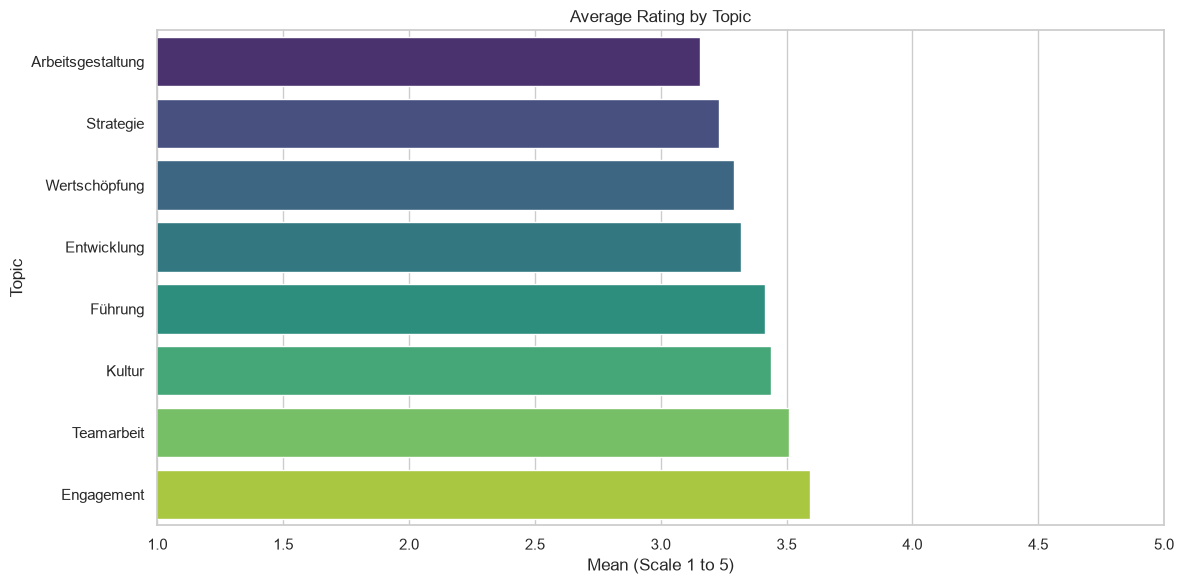

In [297]:
# Sort DataFrame for the plot (ascending, so the highest value is shown at the top of the chart)
df_plot = df_themen.sort_values(by='average_value', ascending=True)

plt.figure(figsize=(12, 6))
sns.barplot(x='average_value', y='topic', data=df_plot, palette='viridis')

# Set plot title and axis labels
plt.title('Average Rating by Topic')
plt.xlabel('Mean (Scale 1 to 5)')
plt.ylabel('Topic')

plt.xlim(1, 5) # Fix the scale from 1 to 5
plt.tight_layout()
plt.show()

In [298]:
# Dictionary to store statistical metrics for each topic
thema_stats = {}

for name, spalten_liste in kategorien_dict.items():
    # Calculate the average rating per respondent (row) for the current category
    row_means = data[spalten_liste].mean(axis=1)
    
    # Store key descriptive statistics for the topic
    thema_stats[name] = {
        'average_value': row_means.mean(),
        'std': row_means.std(),
        'min': row_means.min(),
        'max': row_means.max(),
        'n_respondents': row_means.notnull().sum()
    }

# Convert the results to a DataFrame, transpose it, and sort by average value
df_thema_stats = pd.DataFrame(thema_stats).T.sort_values('average_value', ascending=True)

# Display the statistics table
display(df_thema_stats)

,average_value,std,min,max,n_respondents
Arbeitsgestaltung,3.154714,0.740129,1.142857,4.857143,500.0
Strategie,3.232333,0.721008,1.166667,4.833333,500.0
Wertschöpfung,3.289587,0.670737,1.222222,4.888889,500.0
Entwicklung,3.319229,0.714724,1.333333,4.857143,500.0
Führung,3.412767,0.649433,1.333333,4.833333,500.0
Kultur,3.437086,0.738461,1.333333,5.000000,500.0
Teamarbeit,3.509733,0.923758,1.000000,5.000000,500.0
Engagement,3.592900,0.511682,2.000000,5.000000,500.0


In [326]:
# Save the topic scores for later analysis (e.g., correlation, modeling)
for name, spalten_liste in kategorien_dict.items():
    # Properly replace umlauts and spaces
    clean_name = (
        name.lower()
        .replace(" ", "_")
        .replace("ä", "ae")
        .replace("ö", "oe")
        .replace("ü", "ue")
    )
    data[f'{clean_name}_score'] = data[spalten_liste].mean(axis=1)

# Example: New columns in the DataFrame
print(data.filter(like='_score').columns.tolist())

['teamarbeit_score', 'kultur_score', 'fuehrung_score', 'strategie_score', 'arbeitsgestaltung_score', 'entwicklung_score', 'wertschoepfung_score', 'engagement_score']


...

### 🎯 Key Insights

#### Ranking of Topic Areas

| Rank | Topic | Mean | Interpretation | Details |
| :--- | :--- | :--- | :--- | :--- |
| 🥇 1 | Engagement | 3.59 | ✅ Strongest area (work-life balance, job satisfaction, recognition) | 🟢 Top Topic – Lowest Std (0.51) → high consensus; Min = 2.0 → no extreme negative outliers. Work-life balance and job satisfaction are genuine strengths. |
| 🥈 2 | Teamwork | 3.51 | ✅ Team culture works well | 🟢 High Std (0.92) → differences between individuals, but overall positive; Min = 1.0 → some individuals have very negative team experiences. |
| 🥉 3 | Culture | 3.44 | ✅ Psychological safety, respect, open communication are strong | 🟢 Moderate Std (0.74) → relatively consistent; Max = 5.0 → some rate culture very highly. Items: `psychologische_sicherheit`, respekt, `offene_kommunikation`, `fehlerkultur_keine_vorwuerfe`. |
| 4 | Leadership | 3.41 | ⚠️ Solid, but room for improvement | 🟢 Lowest Std (0.65) → high consensus; Min = 1.33 → no extreme outliers. Items: `rahmenbedingungen_change` (4.21, very high), `info_fuehrung_veraenderung`, `ehrlichkeit_fuehrung`. Change framework is good, but leadership communication could be better. |
| 5 | Development | 3.32 | ⚠️ Learning and development opportunities are mediocre | 🟡 Moderate Std (0.71); Min = 1.33. Items: `anforderung_faehigkeit_match` (2.88, lowest individual score!), `neues_lernen` (3.42), `anspruchsvolle_aufgaben` (3.44). Skill-job-fit is the biggest individual issue in the development area. |
| 6 | Value Creation | 3.29 | ⚠️ Customer/process focus could be better | 🟡 Lowest Std (0.67) → high consensus on mediocrity; Min = 1.22. Items: `tools_technologien` (3.16), `prozesse_hinterfragen` (3.39), kundenfokus (3.33). Process quality and tools could be improved. |
| 7 | Strategy | 3.23 | ⚠️ Strategic clarity is an area for action | 🟡 Moderate Std (0.72); Min = 1.17. Items: strategieklarheit (3.10), `klare_ziele` (3.11), `zielbeitrag_strategie` (3.12), `info_geschaeftslage` (3.30). Strategic direction and sense of purpose are unclear. |
| 8 | Job Design | 3.15 | 🔴 Lowest score – the biggest problem lies here | 🔴 Priority 1 – Moderate Std (0.74); Min = 1.14. Items: gestaltungsspielraum (3.18), `klare_ziele` (3.11), `einfluss_arbeitsmenge` (3.16), erwartungsklarheit (3.13), `verantwortung_foerderung` (3.13). Employees want more autonomy, clearer goals, and better influence over their workload. |

...

---

### Correlations

---

### By Topic Group

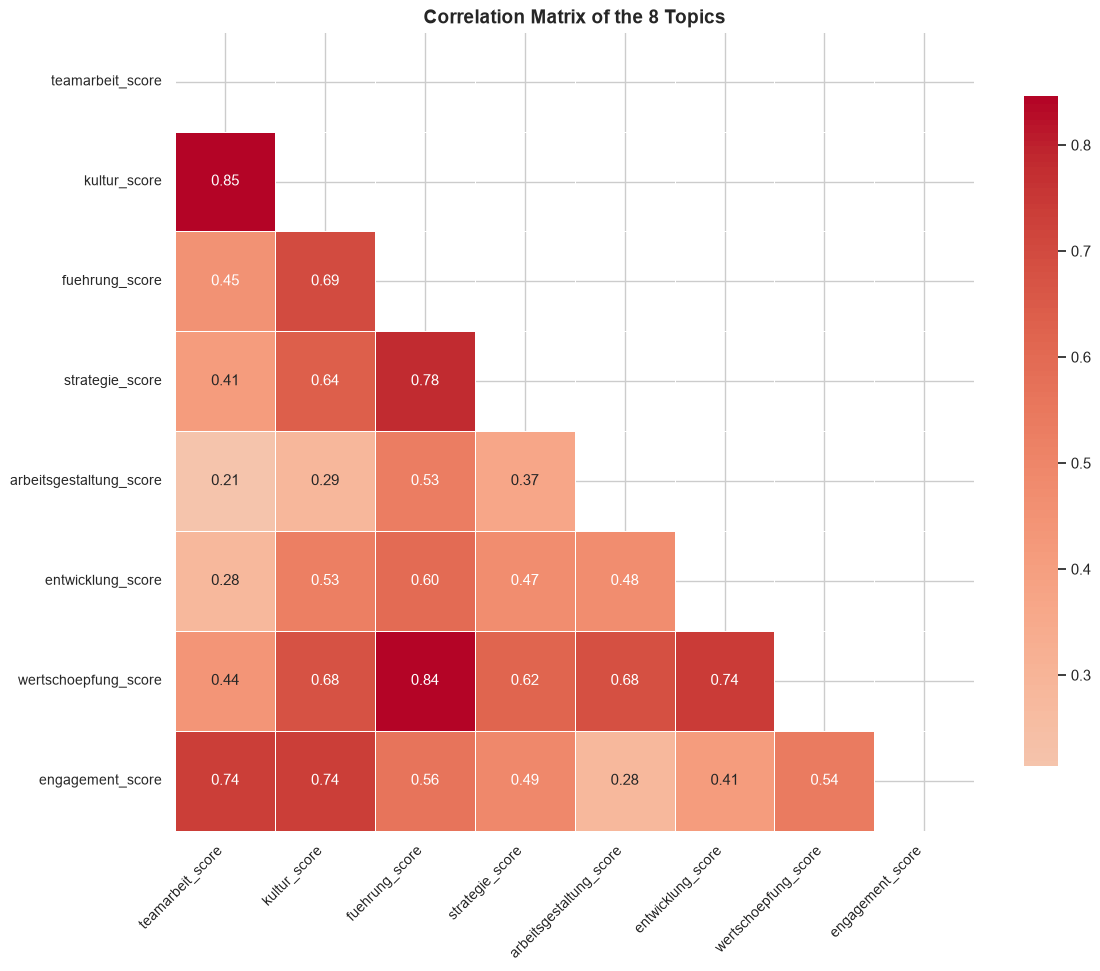

,teamarbeit_score,kultur_score,fuehrung_score,strategie_score,arbeitsgestaltung_score,entwicklung_score,wertschoepfung_score,engagement_score
teamarbeit_score,1.00,0.85,0.45,0.41,0.21,0.28,0.44,0.74
kultur_score,0.85,1.00,0.69,0.64,0.29,0.53,0.68,0.74
fuehrung_score,0.45,0.69,1.00,0.78,0.53,0.60,0.84,0.56
strategie_score,0.41,0.64,0.78,1.00,0.37,0.47,0.62,0.49
arbeitsgestaltung_score,0.21,0.29,0.53,0.37,1.00,0.48,0.68,0.28
entwicklung_score,0.28,0.53,0.60,0.47,0.48,1.00,0.74,0.41
wertschoepfung_score,0.44,0.68,0.84,0.62,0.68,0.74,1.00,0.54
engagement_score,0.74,0.74,0.56,0.49,0.28,0.41,0.54,1.00


In [325]:
# Topic score columns
score_cols = [
    'teamarbeit_score',
    'kultur_score',
    'fuehrung_score',
    'strategie_score',
    'arbeitsgestaltung_score',
    'entwicklung_score',
    'wertschoepfung_score',
    'engagement_score'
]

# Calculate the correlation matrix
corr_matrix = data[score_cols].corr()

# Create the heatmap
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Upper triangle mask

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    annot_kws={'fontsize': 11}
)

plt.title('Correlation Matrix of the 8 Topics', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

# Correlation matrix as a table
display(corr_matrix.round(2))

...

### 🎯 Key Insights: Correlation Analysis of Topic Scores

The correlation matrix reveals clear thematic clusters and strong interdependencies between the different topic scores.

#### 1. 📊 Strongest Correlations

| Relationship | Correlation (r) | Strength | Interpretation & Details |
| :--- | :--- | :--- | :--- |
| `teamarbeit_score` ↔ `kultur_score` | 0.85 | 🔵 Very strong | Team climate and cultural safety are deeply intertwined. |
| `fuehrung_score` ↔ `wertschoepfung_score` | 0.84 | 🔵 Very strong | Leadership and operational/content value creation are highly coupled. |
| `fuehrung_score` ↔ `strategie_score` | 0.78 | 🟢 Strong | Strategic clarity and leadership behavior show a closely aligned pattern. |
| `teamarbeit_score` ↔ `engagement_score` | 0.74 | 🟢 Strong | Employee engagement is strongly linked to team collaboration. |
| `kultur_score` ↔ `engagement_score` | 0.74 | 🟢 Strong | Employee engagement is strongly linked to organizational culture. |
| `wertschoepfung_score` ↔ `entwicklung_score` | 0.74 | 🟢 Strong | Learning/development and process/customer focus run closely in parallel. |

#### 2. 💡 Interpretation for Exploratory Data Analysis (EDA)

| Aspect | Key Finding | Details |
| :--- | :--- | :--- |
| **Positive System Dynamics** | Interconnected overall system | Positive perceptions of culture, teamwork, or leadership generally coincide with higher ratings in strategy, value creation, and engagement. |
| **Distinct Profiles Exist** | Topics are not entirely redundant | Moderate correlations exist in other areas. For instance, `arbeitsgestaltung_score` correlates with other topics only in the 0.2 to 0.5 range, maintaining its distinct profile. |

#### 3. 🛠️ Key Takeaways and Implications

| Area | Strategic Recommendation / Implication |
| :--- | :--- |
| **Thematic Clustering** | Instead of eight completely independent topics, the dataset likely contains 2–3 larger overarching clusters. |
| **Dimensionality Reduction** | For future statistical modeling, highly correlated topics can be evaluated for consolidation into overarching dimensions. |
| **Integrated Reporting** | Use the matrix to demonstrate that team, culture, and leadership are deeply connected and should be addressed with holistic, joint initiatives rather than isolated measures. |

#### 📝 Summary Conclusion

The correlation matrix validates the thematic structure of the survey while highlighting that engagement, teamwork, culture, leadership, and value creation are heavily interwoven. The most clearly separated, independent dimensions are `arbeitsgestaltung_score` and, to some extent, `entwicklung_score`.

...

### 🎯 Correlation Strength according to Cohen (1988)

| Correlation (r) | Strength | Interpretation |
| :--- | :--- | :--- |
| 0.00 – 0.09 | 🔴 Very weak | No relevant relationship |
| 0.10 – 0.29 | 🟡 Weak | Slight relationship |
| 0.30 – 0.49 | 🟠 Moderate | Moderate relationship |
| 0.50 – 0.79 | 🟢 Strong | Strong relationship |
| 0.80 – 1.00 | 🔵 Very strong | Very strong relationship |

### By Item

In [328]:
data.head()

,start,ende,organisation,bereich,team_effizienz,staerken_nutzen,zusammenarbeit_team,psychologische_sicherheit,info_fuehrung_veraenderung,produktgestaltung_aktiv,...,fuehrung_score,strategie_score,arbeitsgestaltung_score,entwicklung_score,wertschoepfung_score,engagement_score,length,word_count,mean_word_length,mean_sent_length
0,2026-01-02 13:43:00,2026-01-02 13:57:00,[Organization],IN-AL (Innovationsfeld Alpha),5.0,3.0,5.0,5.0,5.0,4.0,...,3.666667,3.500000,3.142857,2.800000,3.333333,4.4,123,19,5.526316,61.00
1,2026-01-04 15:18:00,2026-01-04 15:31:00,[Organization],IN-AL (Innovationsfeld Alpha),4.0,3.0,5.0,5.0,2.0,1.0,...,3.000000,2.166667,2.571429,2.714286,2.777778,3.4,83,14,5.000000,41.00
2,2026-01-03 15:23:00,2026-01-03 15:30:00,[Organization],KE-EP (Kernbereich Epsilon),4.0,3.0,4.0,4.0,3.0,3.0,...,3.000000,2.400000,3.000000,2.833333,3.111111,3.6,146,22,5.681818,72.50
3,2026-01-01 13:00:00,2026-01-01 13:06:00,[Organization],IN-AL (Innovationsfeld Alpha),5.0,4.0,4.0,4.0,4.0,3.0,...,4.333333,3.000000,4.000000,3.714286,3.777778,4.0,222,32,5.968750,54.75
4,2026-01-03 08:42:00,2026-01-03 09:00:00,[Organization],ZU-BE (Zukunftssegment Beta),4.0,2.0,5.0,4.0,4.0,4.0,...,3.666667,4.166667,3.000000,2.833333,3.333333,4.2,388,62,5.274194,76.80


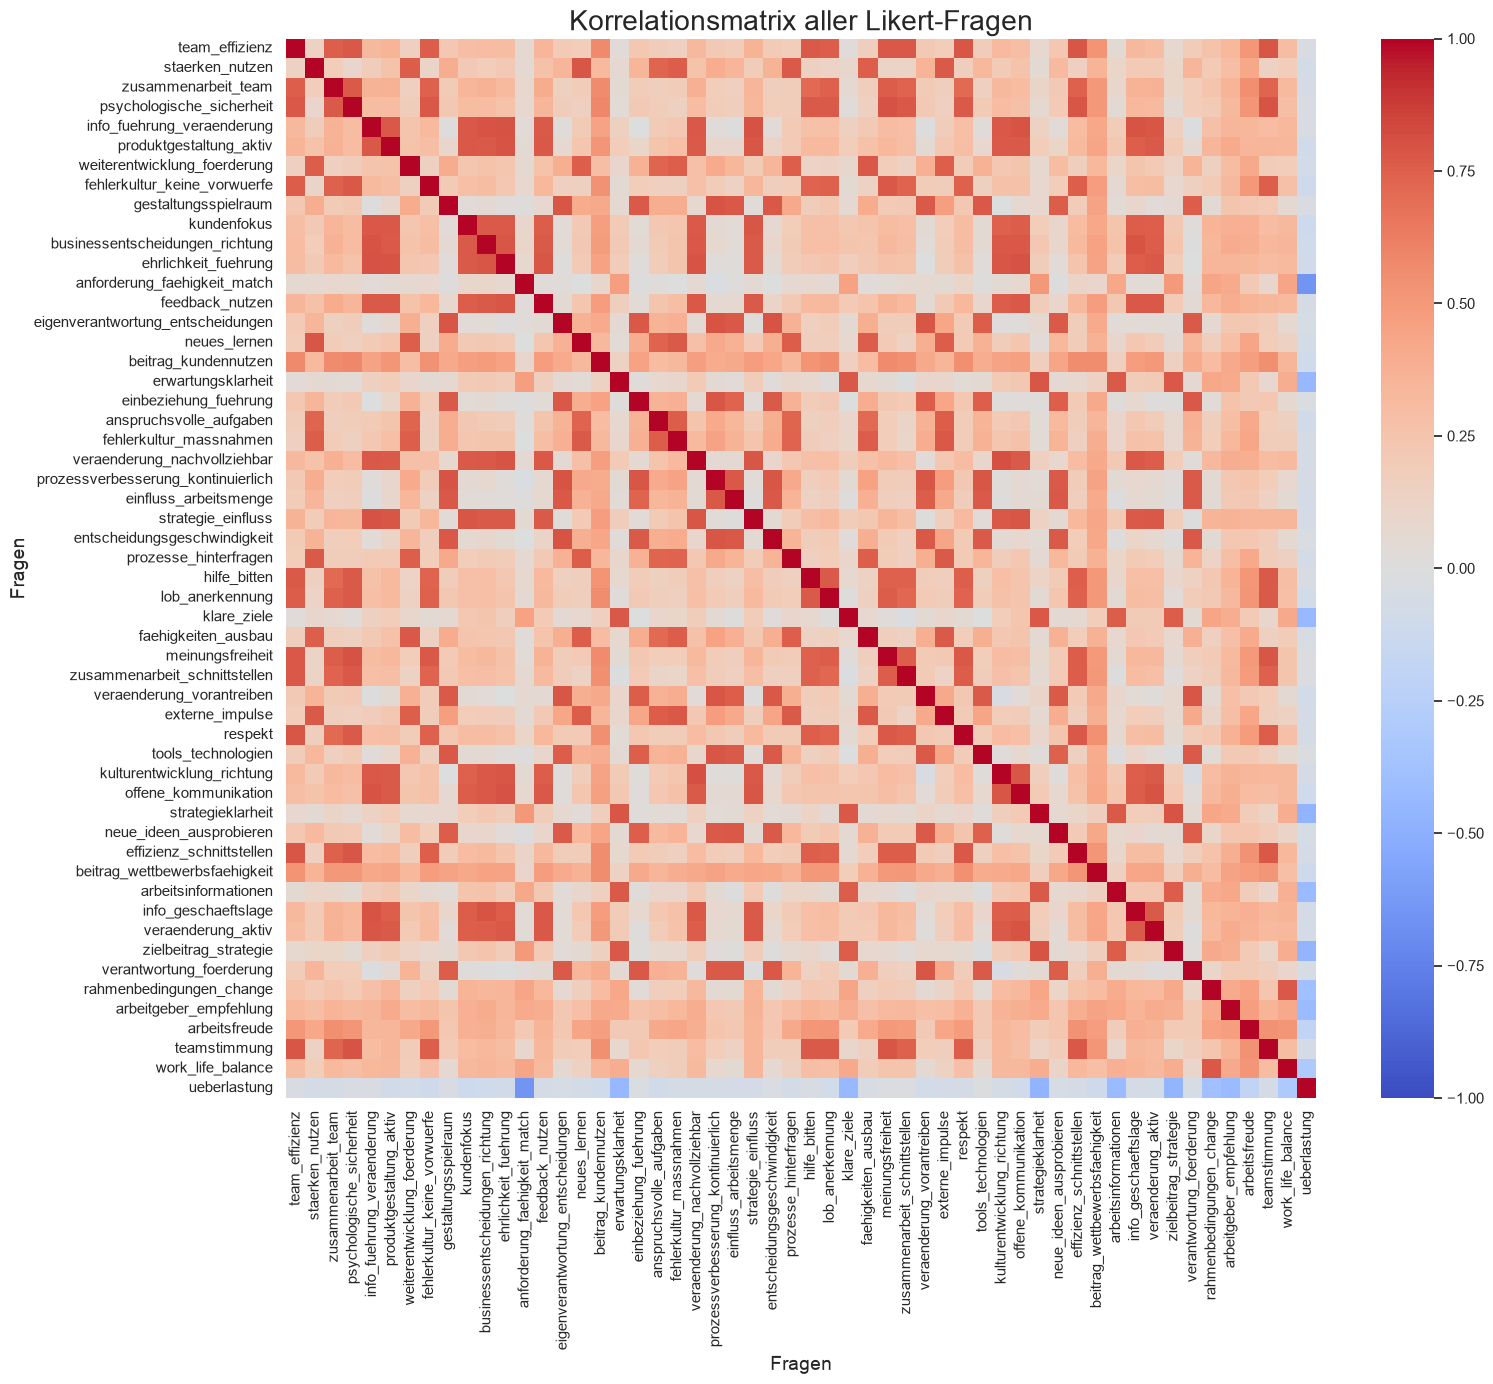

In [327]:
# Nur die umkodierten Likert-Spalten auswählen
cols_likert = cols_to_recode

# Korrelationsmatrix berechnen
korrelation_likert = data[cols_likert].corr()

# Als große Heatmap visualisieren
plt.figure(figsize=(16, 14))
sns.heatmap(korrelation_likert, cmap='coolwarm', vmin=-1, vmax=1, annot=False, cbar=True)
plt.title('Korrelationsmatrix aller Likert-Fragen', fontsize=20)
plt.xlabel('Fragen', fontsize=14)
plt.ylabel('Fragen', fontsize=14)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### Verteilungs-Check der Likert-Skalen (Divergierendes Balkendiagramm)

Um zu sehen, ob Werte polarisieren oder eher neutral ("Teils/Teils", Wert 3) beantwortet werden, betrachten wir die prozentuale Verteilung der Kategorien über alle Likert-Spalten hinweg.

<Figure size 1400x800 with 0 Axes>

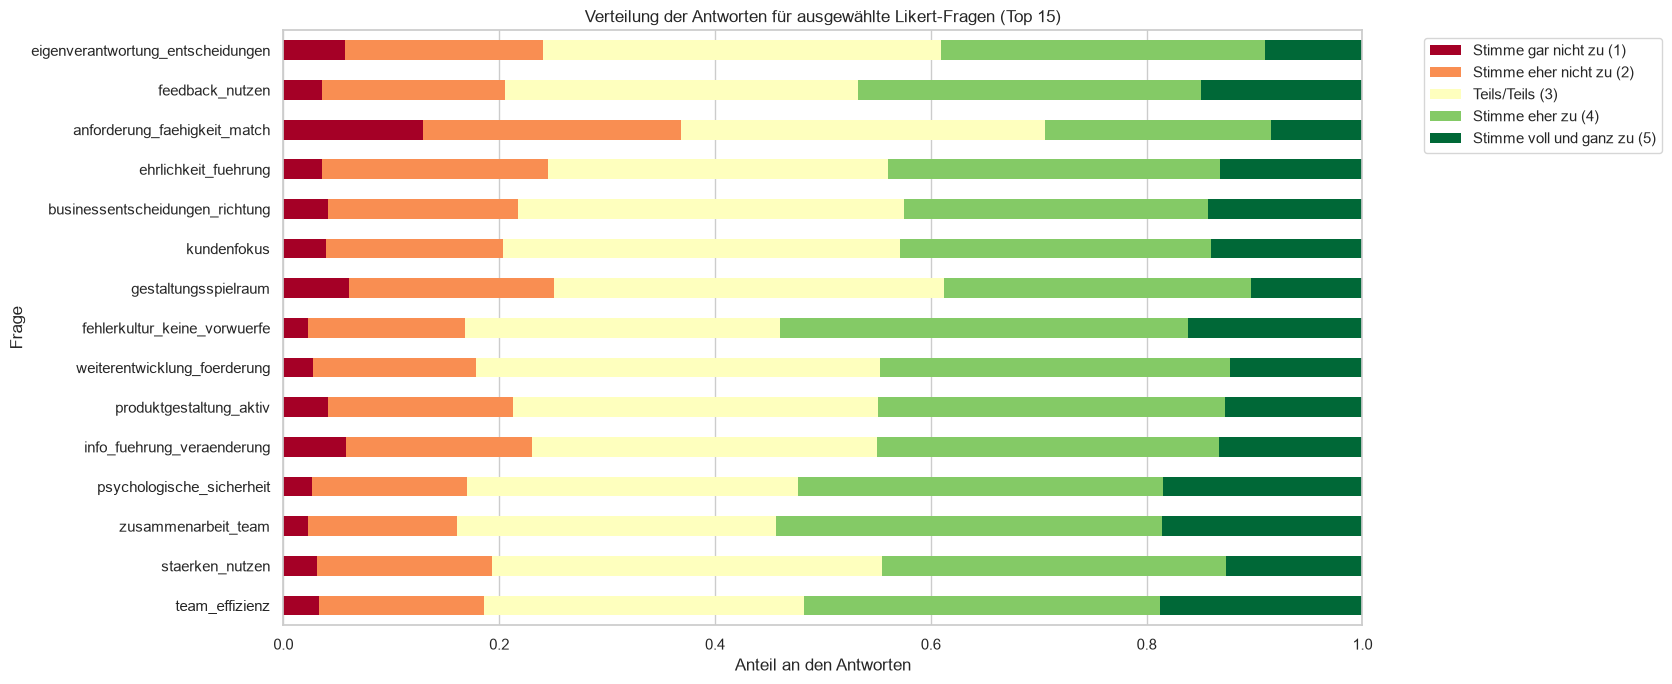

In [301]:
# Alle Likert-Spalten (Werte von 1 bis 5, inklusive NaNs)
cols_likert = cols_to_recode

# Prozentuale Anteile der Likert-Stufen (1 bis 5) pro Spalte berechnen
likert_counts = data[cols_likert].apply(lambda x: x.value_counts(normalize=True)).T.fillna(0)
# Sicherstellen, dass die Spalten 1.0 bis 5.0 existieren
for i in [1.0, 2.0, 3.0, 4.0, 5.0]:
    if i not in likert_counts.columns:
        likert_counts[i] = 0.0

# Nur die relevanten Stufen sortieren
likert_counts = likert_counts[[1.0, 2.0, 3.0, 4.0, 5.0]]
likert_counts.columns = ['Stimme gar nicht zu (1)', 'Stimme eher nicht zu (2)', 'Teils/Teils (3)', 'Stimme eher zu (4)', 'Stimme voll und ganz zu (5)']

# Plotten als 100% gestapeltes Balkendiagramm (Top 15 Fragen zur Übersichtlichkeit)
plt.figure(figsize=(14, 8))
ax = likert_counts.head(15).plot(kind='barh', stacked=True, colormap='RdYlGn', edgecolor='none')
plt.title('Verteilung der Antworten für ausgewählte Likert-Fragen (Top 15)')
plt.xlabel('Anteil an den Antworten')
plt.ylabel('Frage')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

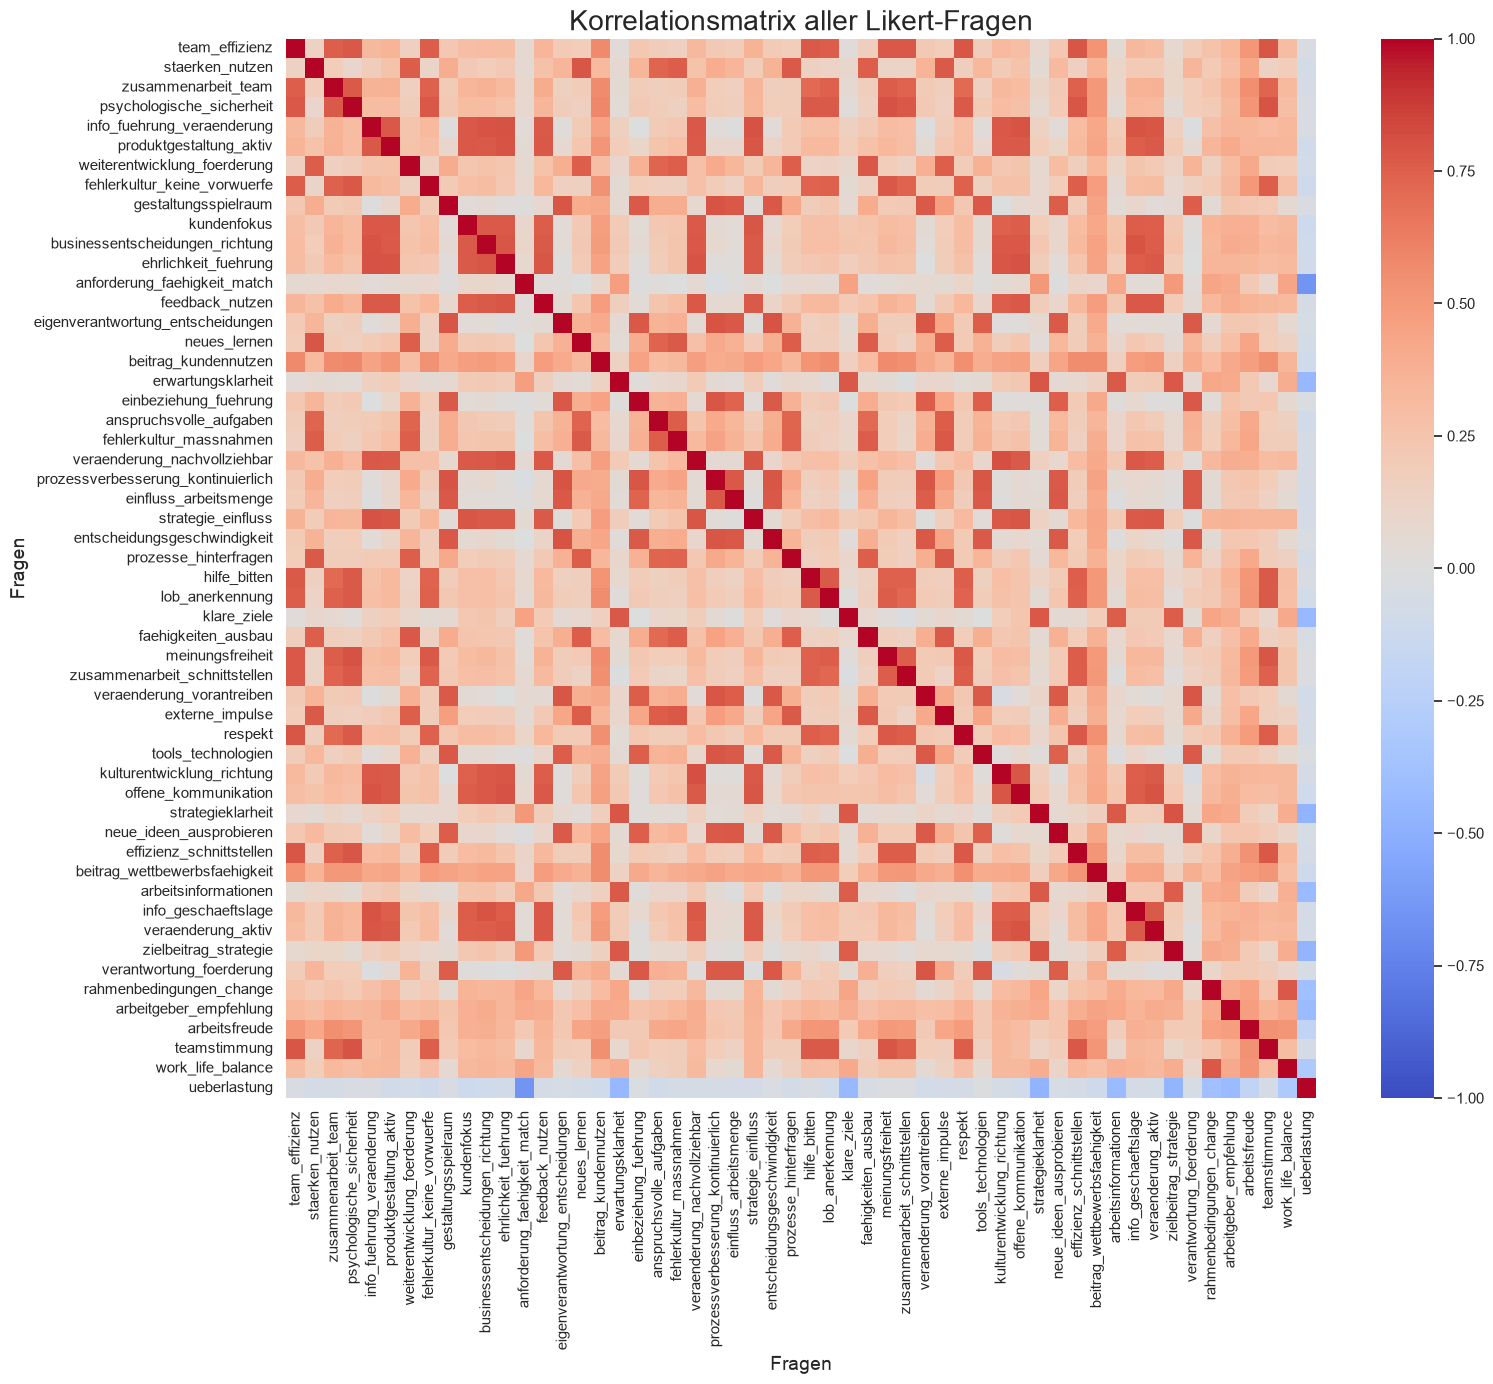

Die Korrelationsmatrix zeigt ein sehr klares und für Organisationsbefragungen typisches Bild. Die zentralen Erkenntnisse daraus:

    Durchgehend positive Zusammenhänge: Fast die gesamte Matrix ist in warmen Rot-Tönen gehalten. Das bedeutet, dass Mitarbeitende, die in einem Bereich (z. B. Teamarbeit oder Kultur) positive Bewertungen abgeben, tendenziell auch in anderen Bereichen überdurchschnittlich zufrieden sind (General-Factor-Effekt / Halo-Effekt).

    Starke interne Cluster: Bestimmte Blöcke (wie Teamarbeit, psychologische Sicherheit und Führung) weisen besonders tiefe Rotausprägungen auf. Diese Faktoren greifen im Arbeitsalltag stark ineinander.

    Auffällige Ausreißer (Blaue Linien): Am rechten Rand (bei den Spalten bzw. Zeilen für work_life_balance und ueberlastung) siehst du deutliche blaue bzw. hellere Linien. Das ist ein wichtiger Indikator: Belastung und Work-Life-Balance verhalten sich gegenläufig oder entkoppelt zu vielen klassischen HR-Zufriedenheitsfaktoren – wer überlastet ist, bewertet andere Prozesse nicht zwangsläufig besser oder schlechter, zeigt hier aber einen interessanten Kontrast, der perfekt zu deiner geplanten Sentiment-Analyse als zusätzliches Feature passt.

<Figure size 1400x1620 with 0 Axes>

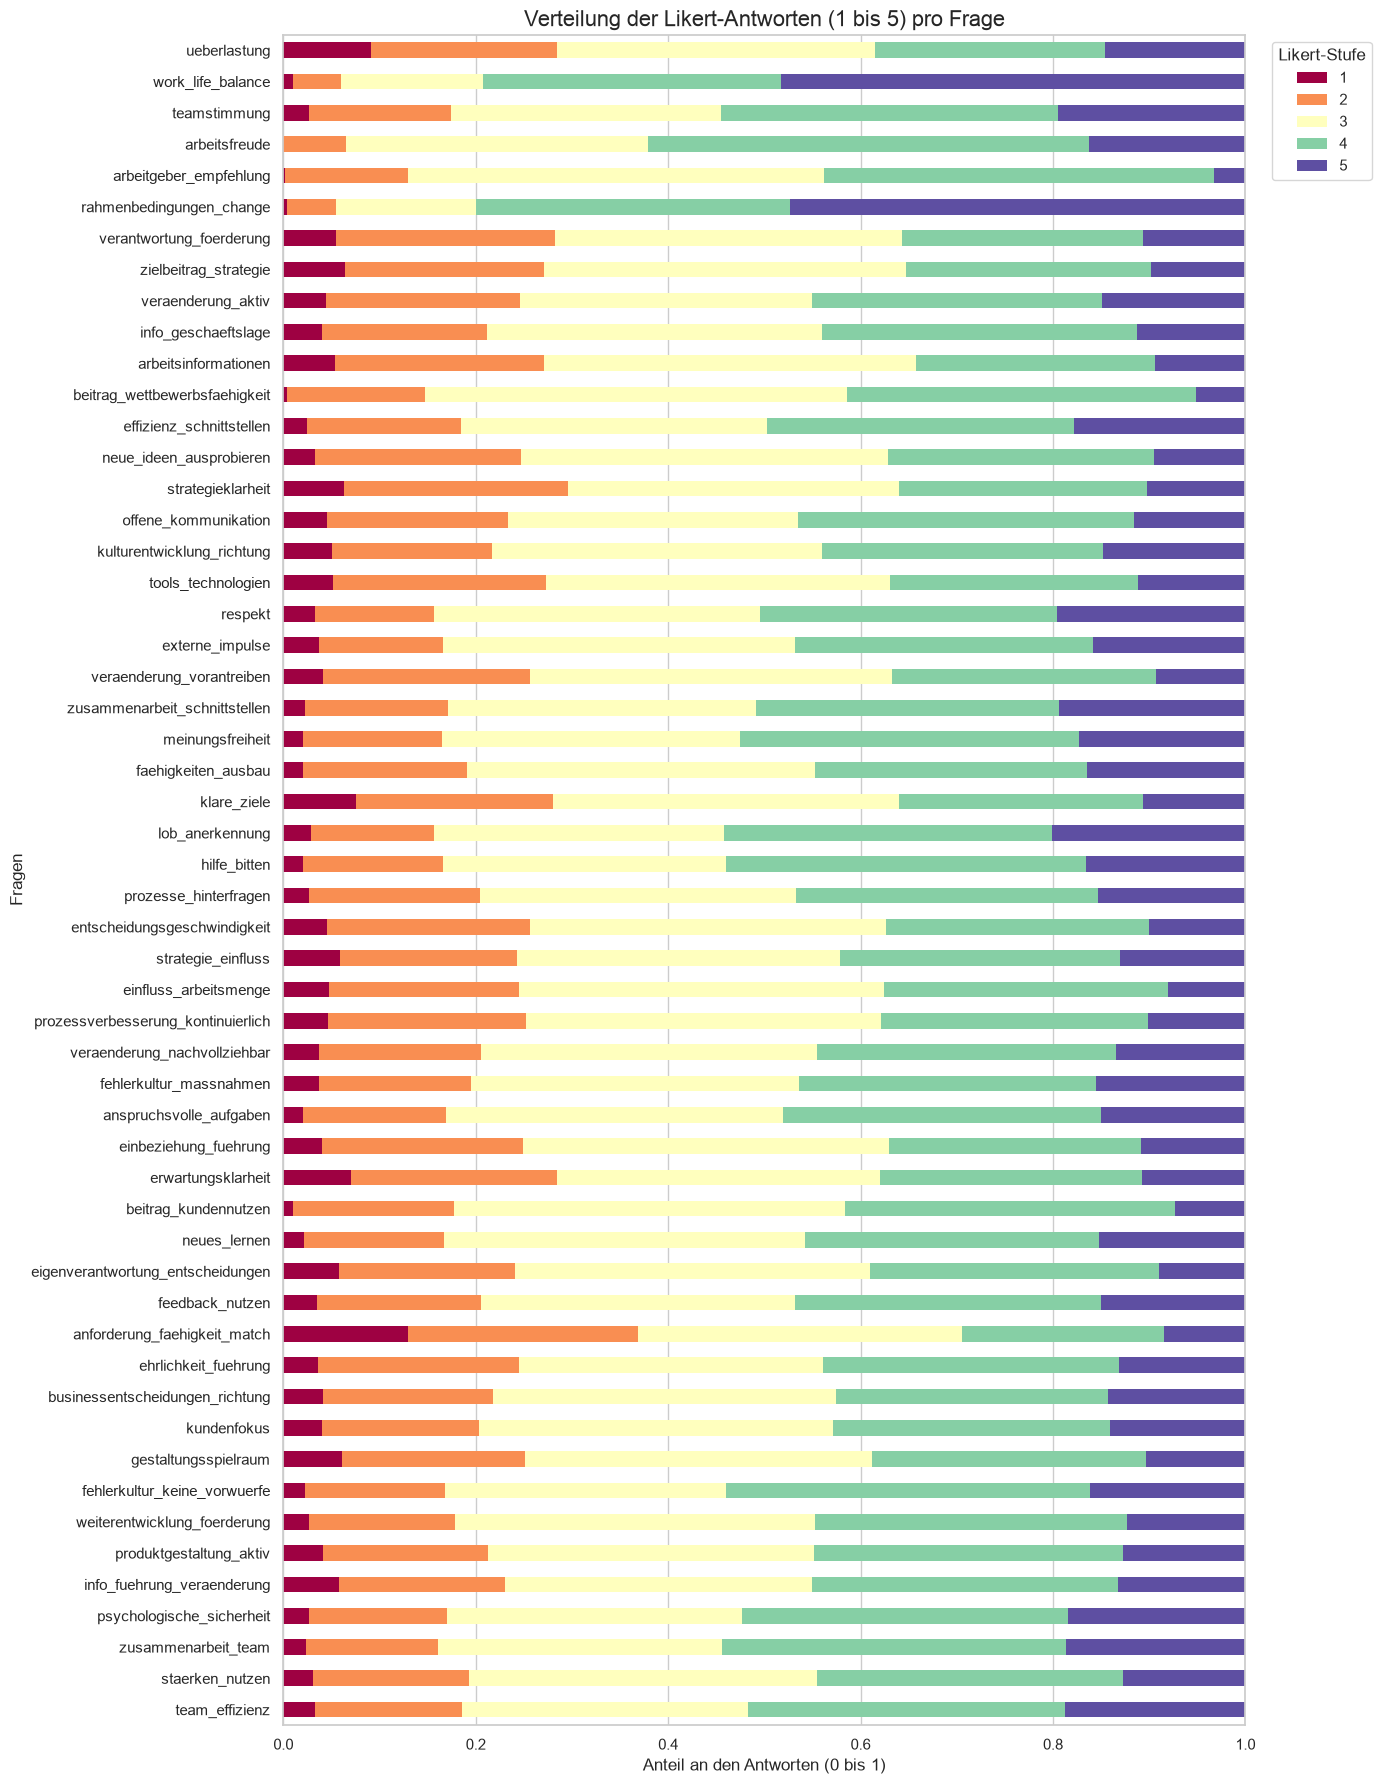

In [303]:
# Berechnung der prozentualen Verteilung (1.0 bis 5.0) für jede Likert-Spalte
verteilung_df = data[cols_likert].apply(lambda x: x.value_counts(normalize=True)).T.fillna(0)

# Sicherstellen, dass die Spalten 1 bis 5 in korrekter Reihenfolge vorliegen
for i in [1.0, 2.0, 3.0, 4.0, 5.0]:
    if i not in verteilung_df.columns:
        verteilung_df[i] = 0.0
verteilung_df = verteilung_df[[1.0, 2.0, 3.0, 4.0, 5.0]]
verteilung_df.columns = ['1', '2', '3', '4', '5']

# Als gestapeltes Balkendiagramm über alle Fragen plotten
plt.figure(figsize=(14, max(10, len(cols_likert) * 0.3)))
ax = verteilung_df.plot(kind='barh', stacked=True, colormap='Spectral', edgecolor='none', figsize=(14, 18))

plt.title('Verteilung der Likert-Antworten (1 bis 5) pro Frage', fontsize=16)
plt.xlabel('Anteil an den Antworten (0 bis 1)', fontsize=12)
plt.ylabel('Fragen', fontsize=12)
plt.legend(title='Likert-Stufe', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

In [304]:
# # Nur die umkodierten Likert-Spalten
# cols_likert = cols_to_recode
# n_cols = 6  # Anzahl der Diagramme pro Zeile
# n_rows = int(np.ceil(len(cols_likert) / n_cols))

# # Raster definieren (jede kleine Grafik wird quadratisch angelegt)
# fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 3), sharey=True)
# axes = axes.flatten()

# # Einheitliche Farbpalette für die Likert-Stufen (1 bis 5)
# palette = sns.color_palette("Spectral", 5)

# for i, col in enumerate(cols_likert):
#     ax = axes[i]
    
#     # Werte zählen und sicherstellen, dass alle Stufen 1-5 vorhanden sind
#     counts = data[col].value_counts().reindex([1.0, 2.0, 3.0, 4.0, 5.0], fill_value=0)
    
#     # Prozentwerte berechnen
#     prozent = counts / counts.sum()
    
#     # Kleines Balkendiagramm zeichnen
#     ax.bar([1, 2, 3, 4, 5], prozent, color=palette, width=0.8)
    
#     # Layout anpassen für "quadratischen" Look und Lesbarkeit
#     ax.set_title(col, fontsize=9, wrap=True)
#     ax.set_ylim(0, 1)
#     ax.set_xticks([1, 2, 3, 4, 5])
#     ax.set_xticklabels(['1', '2', '3', '4', '5'], fontsize=8)
#     ax.tick_params(axis='y', labelsize=8)
#     ax.grid(axis='y', linestyle='--', alpha=0.5)

# # Zu űberflüssige Subplots (falls das Raster größer ist als die Spaltenanzahl) ausblenden
# for j in range(i + 1, len(axes)):
#     fig.delaxes(axes[j])

# plt.suptitle("Verteilung der Likert-Antworten (1-5) je Frage", fontsize=16, y=1.02)
# plt.tight_layout()
# plt.show()

In [305]:
# # Korrelationsmatrix für Ihre Themen-Mittelwerte oder Kernfragen berechnen
# plt.figure(figsize=(10, 8))
# sns.heatmap(data[fuehrung].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
# plt.title('Korrelation innerhalb des Themenbereichs Führung')
# plt.show()

---
### Missing Values 

---

In [ ]:
# Anzahl der fehlenden Werte
missing_count = data.isnull().sum()

# Anteil in Prozent
missing_percent = (data.isnull().sum() / len(data)) * 100

# In einem gemeinsamen DataFrame zusammenfassen
missing_df = pd.DataFrame({
    'Fehlende Werte': missing_count,
    'Prozent (%)': missing_percent
})

# Nach Anzahl der fehlenden Werte absteigend sortieren
print(missing_df.sort_values(by='Fehlende Werte', ascending=False))

                                    Fehlende Werte  Prozent (%)
prozessverbesserung_kontinuierlich              28          5.6
gestaltungsspielraum                            26          5.2
rahmenbedingungen_change                        25          5.0
veraenderung_aktiv                              25          5.0
kundenfokus                                     24          4.8
...                                            ...          ...
iteration_id                                     0          0.0
ende                                             0          0.0
bereich                                          0          0.0
organisation                                     0          0.0
engagement_score                                 0          0.0

[70 rows x 2 columns]


In [307]:
missing_columns = data.isnull().sum()
print(missing_columns[missing_columns > 0])

team_effizienz                        15
staerken_nutzen                       19
zusammenarbeit_team                   22
psychologische_sicherheit             18
info_fuehrung_veraenderung            18
produktgestaltung_aktiv               12
weiterentwicklung_foerderung          19
fehlerkultur_keine_vorwuerfe          18
gestaltungsspielraum                  26
kundenfokus                           24
businessentscheidungen_richtung       18
ehrlichkeit_fuehrung                  22
anforderung_faehigkeit_match          14
feedback_nutzen                       19
eigenverantwortung_entscheidungen     13
neues_lernen                          22
beitrag_kundennutzen                  20
erwartungsklarheit                    15
einbeziehung_fuehrung                 22
anspruchsvolle_aufgaben               15
fehlerkultur_massnahmen               17
veraenderung_nachvollziehbar          17
prozessverbesserung_kontinuierlich    28
einfluss_arbeitsmenge                 15
strategie_einflu

In [308]:

# Füllt NaN in der Textspalte mit einem leeren String auf
data['freitext_kommentar'] = data['freitext_kommentar'].fillna("")


In [309]:
# Zählt die verbleibenden Missing Values in der Spalte
missing_count = data['freitext_kommentar'].isna().sum()
print(f"Anzahl verbleibender NaN-Werte: {missing_count}")

Anzahl verbleibender NaN-Werte: 0


In [310]:
# Zählt, wie oft ein exakt leerer String vorkommt
leere_strings_count = (data['freitext_kommentar'] == "").sum()
print(f"Anzahl erfolgreicher leerer Strings: {leere_strings_count}")


Anzahl erfolgreicher leerer Strings: 18


---
## Exploratory Data Analysis on Qualitative Feedback
---
### Counts and Lenght:
Start by checking how long the reviews are
* Character count
* Word count
* Mean word length
* Mean sentence length

### Character count

In [311]:
lenght = len(data['freitext_kommentar'][0])
print(f'Length of a sample feedback: {lenght}')

Length of a sample feedback: 123


In [312]:
data['length'] = data['freitext_kommentar'].str.len()
data[['freitext_kommentar', 'length']].head(10)

,freitext_kommentar,length
0,"Ehrlich gesagt: Ich weiß genau, woran ich arbe...",123
1,Bringt ja eh nichts. Wissen hängt bei uns an e...,83
2,"Ich finde die Richtung richtig, auch wenn der ...",146
3,"Ehrlich, ich kann nicht mehr. Konflikte werden...",222
4,Aus meiner Sicht: Die neue Struktur ergibt für...,388
5,Ich hatte mehr erwaret. In meinen ersten Woche...,148
6,Ich mache mir Sorgen. Entwicklungsgespräche si...,465
7,Vielleicht wird es ja gerade besser. Dass wir ...,242
8,Die letzte Gehaltsrunde war fair und nachvollz...,138
9,"vielen dank dafür: ich merke, das meine erfahr...",64


In [313]:
data['length'].describe()

count    500.000000
mean     176.592000
std      104.802522
min        0.000000
25%       97.000000
50%      158.000000
75%      232.250000
max      608.000000
Name: length, dtype: float64

### Word Count: Number of Words in a Feedback

In [314]:
word_count = data['freitext_kommentar'][0].split()
print(f'Word count in a sample review: {len(word_count)}')

Word count in a sample review: 19


In [315]:
def word_count(feedback):
    feedback_list = feedback.split()
    return len(feedback_list)

In [316]:
data['word_count'] = data['freitext_kommentar'].apply(word_count)
data[['freitext_kommentar','length','word_count']].head(10)

,freitext_kommentar,length,word_count
0,"Ehrlich gesagt: Ich weiß genau, woran ich arbe...",123,19
1,Bringt ja eh nichts. Wissen hängt bei uns an e...,83,14
2,"Ich finde die Richtung richtig, auch wenn der ...",146,22
3,"Ehrlich, ich kann nicht mehr. Konflikte werden...",222,32
4,Aus meiner Sicht: Die neue Struktur ergibt für...,388,62
5,Ich hatte mehr erwaret. In meinen ersten Woche...,148,25
6,Ich mache mir Sorgen. Entwicklungsgespräche si...,465,77
7,Vielleicht wird es ja gerade besser. Dass wir ...,242,37
8,Die letzte Gehaltsrunde war fair und nachvollz...,138,19
9,"vielen dank dafür: ich merke, das meine erfahr...",64,11


In [317]:
data['word_count'].describe()

count    500.000000
mean      28.184000
std       16.790533
min        0.000000
25%       15.750000
50%       25.000000
75%       37.000000
max       94.000000
Name: word_count, dtype: float64

#### **Mean word length**: Average length of words

In [318]:
data['mean_word_length'] = data['freitext_kommentar'].map(lambda rev: np.mean([len(word) for word in rev.split()]))
data[['freitext_kommentar','length','word_count','mean_word_length']].head(10)

,freitext_kommentar,length,word_count,mean_word_length
0,"Ehrlich gesagt: Ich weiß genau, woran ich arbe...",123,19,5.526316
1,Bringt ja eh nichts. Wissen hängt bei uns an e...,83,14,5.000000
2,"Ich finde die Richtung richtig, auch wenn der ...",146,22,5.681818
3,"Ehrlich, ich kann nicht mehr. Konflikte werden...",222,32,5.968750
4,Aus meiner Sicht: Die neue Struktur ergibt für...,388,62,5.274194
5,Ich hatte mehr erwaret. In meinen ersten Woche...,148,25,4.960000
6,Ich mache mir Sorgen. Entwicklungsgespräche si...,465,77,5.051948
7,Vielleicht wird es ja gerade besser. Dass wir ...,242,37,5.567568
8,Die letzte Gehaltsrunde war fair und nachvollz...,138,19,6.315789
9,"vielen dank dafür: ich merke, das meine erfahr...",64,11,4.909091


#### **Mean sentence length**: Average length of the sentences in the feedback

In [319]:
np.mean([len(sent) for sent in tokenize.sent_tokenize(data['freitext_kommentar'][0])])

np.float64(61.0)

In [320]:
data['mean_sent_length'] = data['freitext_kommentar'].map(lambda rev: np.mean([len(sent) for sent in tokenize.sent_tokenize(rev)]))
data[['freitext_kommentar','length','word_count','mean_word_length','mean_sent_length']].head(10)

# mean_sent_length = durchschnittliche Anzahl an Zeichen pro Satz

,freitext_kommentar,length,word_count,mean_word_length,mean_sent_length
0,"Ehrlich gesagt: Ich weiß genau, woran ich arbe...",123,19,5.526316,61.000000
1,Bringt ja eh nichts. Wissen hängt bei uns an e...,83,14,5.000000,41.000000
2,"Ich finde die Richtung richtig, auch wenn der ...",146,22,5.681818,72.500000
3,"Ehrlich, ich kann nicht mehr. Konflikte werden...",222,32,5.968750,54.750000
4,Aus meiner Sicht: Die neue Struktur ergibt für...,388,62,5.274194,76.800000
5,Ich hatte mehr erwaret. In meinen ersten Woche...,148,25,4.960000,48.666667
6,Ich mache mir Sorgen. Entwicklungsgespräche si...,465,77,5.051948,65.571429
7,Vielleicht wird es ja gerade besser. Dass wir ...,242,37,5.567568,59.750000
8,Die letzte Gehaltsrunde war fair und nachvollz...,138,19,6.315789,68.500000
9,"vielen dank dafür: ich merke, das meine erfahr...",64,11,4.909091,31.500000


1. Verteilung der einzelnen Metriken (Univariate Analyse)

Um zu sehen, wie sich die Werte über alle Kommentare hinweg verteilen (z. B. ob die Wortanzahl rechtsschief ist).

    Histograms mit Kernel Density Estimation (KDE): Perfekt, um die Verteilung von word_count oder mean_word_length zu zeigen.

    Boxplots: Ideal, um Ausreißer zu erkennen (z. B. extrem lange oder extrem kurze Kommentare).

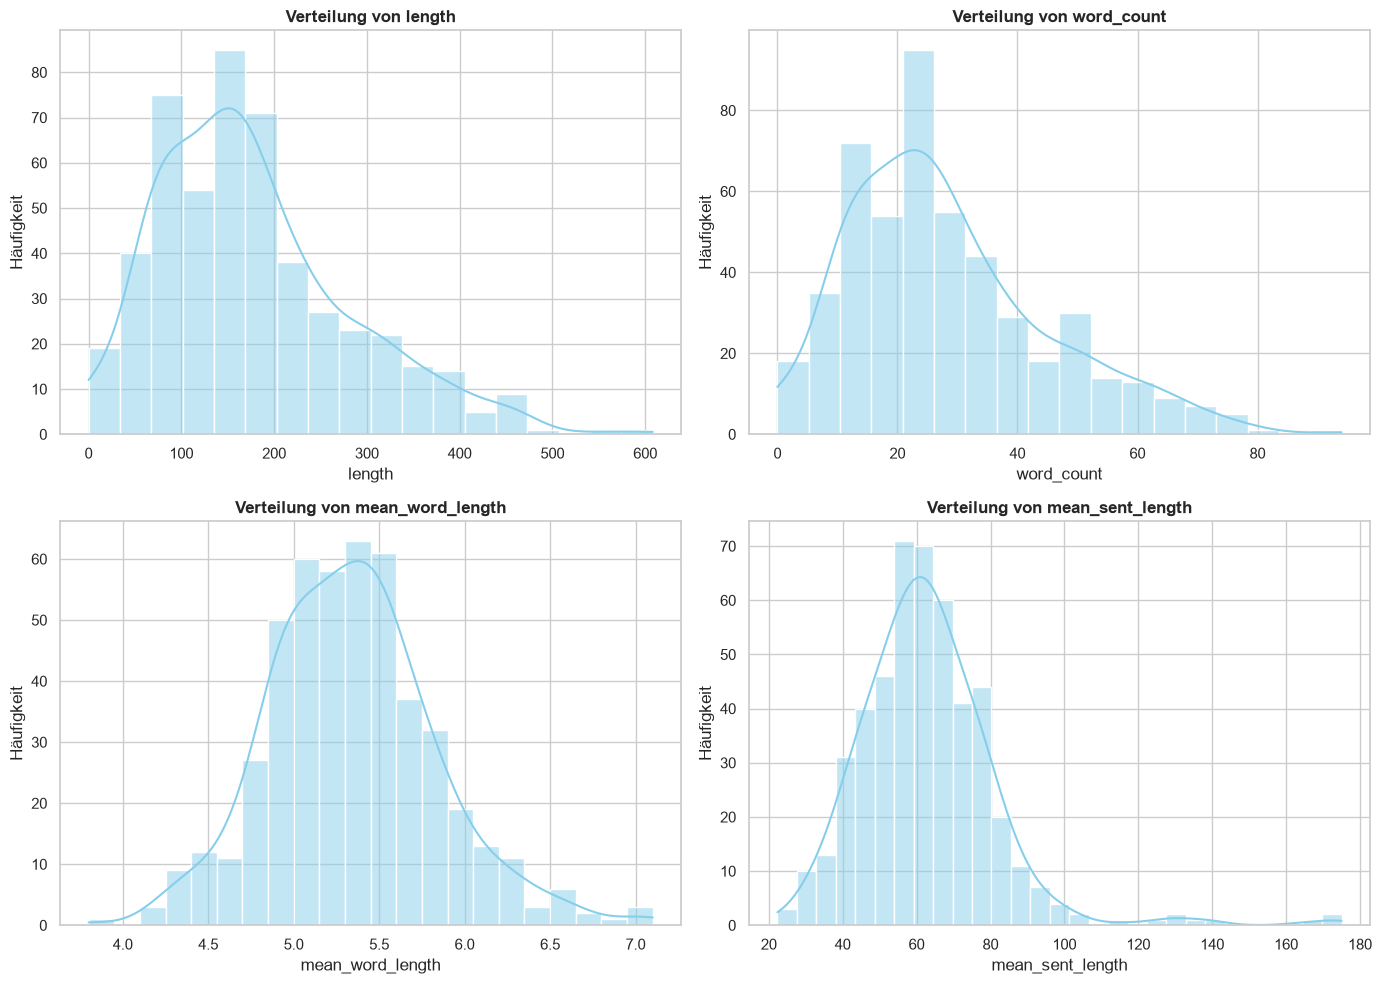

In [321]:

# Spaltennamen aus deiner EDA:
# 'length', 'word_count', 'mean_word_length', 'mean_sent_length'

text_metrics = ['length', 'word_count', 'mean_word_length', 'mean_sent_length']

# Stil für die Plots festlegen
sns.set_theme(style='whitegrid')

# 1. Histogramme mit KDE für alle Metriken
plt.figure(figsize=(14, 10))
for i, col in enumerate(metrics, 1):
  plt.subplot(2, 2, i)
  sns.histplot(data=data, x=col, kde=True, color='skyblue')
  plt.title(f'Verteilung von {col}', fontsize=12, fontweight='bold')
  plt.xlabel(col)
  plt.ylabel('Häufigkeit')

plt.tight_layout()
plt.show()


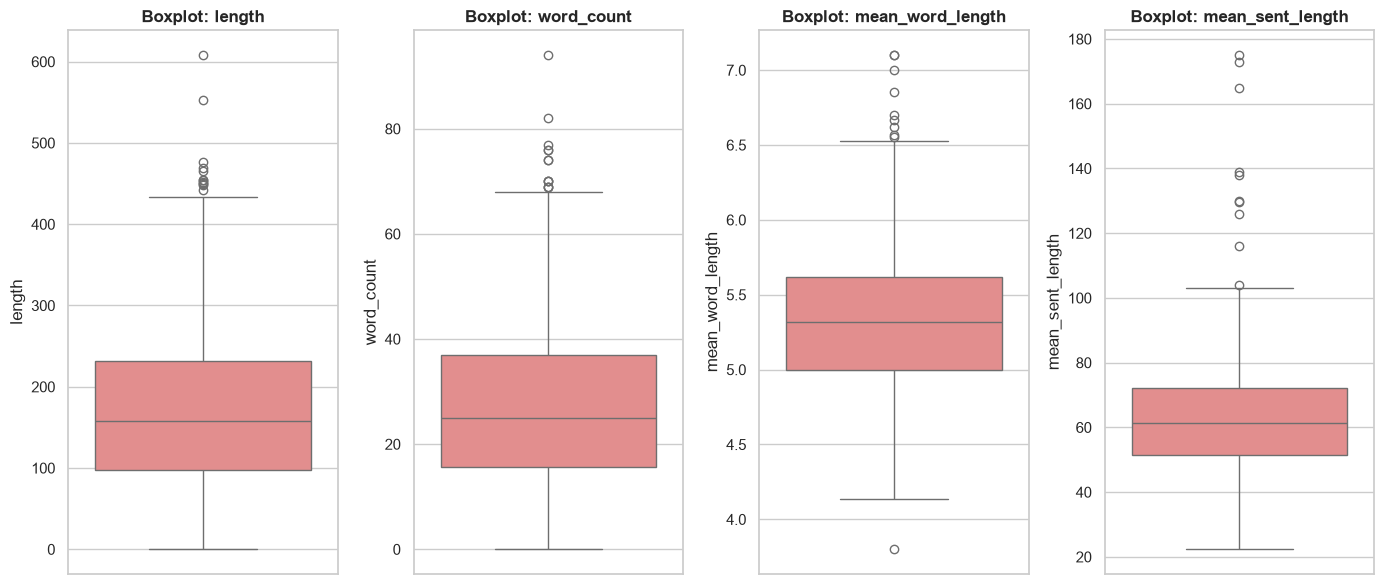

In [322]:

# 2. Boxplots zur Erkennung von Ausreißern
plt.figure(figsize=(14, 6))
for i, col in enumerate(metrics, 1):
  plt.subplot(1, 4, i)
  sns.boxplot(y=data[col], color='lightcoral')
  plt.title(f'Boxplot: {col}', fontsize=12, fontweight='bold')
  plt.ylabel(col)

plt.tight_layout()
plt.show()

2. Beziehungen zwischen den Textmerkmalen (Bivariate Analyse)

Hier prüfst du, wie die Metriken miteinander korrelieren.

    Scatterplots (Streudiagramme):

        Beispiel: word_count auf der X-Achse und length (Zeichenanzahl) auf der Y-Achse. (Hier erwartet man eine starke lineare Korrelation).

        Beispiel: mean_word_length vs. mean_sent_length, um zu sehen, ob längere Sätze auch aus längeren Wörtern bestehen.

    Korrelations-Heatmap: Wenn du noch weitere numerische Spalten hast (oder Sentiment-Scores), zeigt eine Heatmap schnell alle Zusammenhänge auf einen Blick.

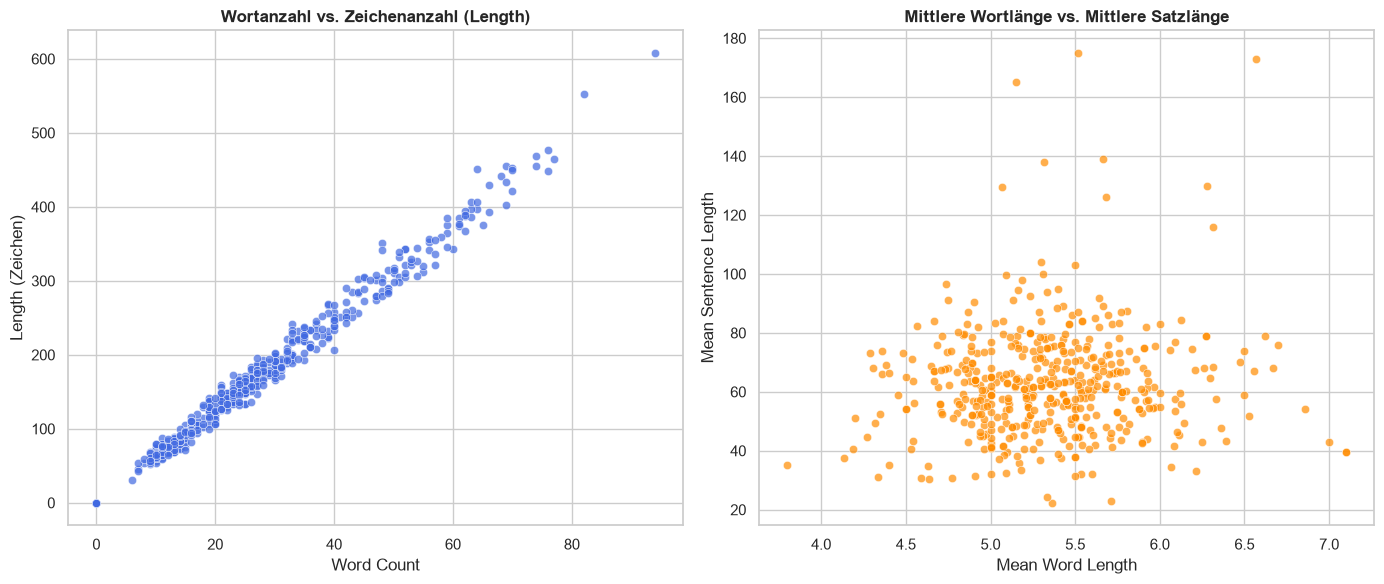

In [323]:
# Vorbereitung: Stil festlegen
sns.set_theme(style='whitegrid')

# 1. Scatterplots (Streudiagramme)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatterplot 1: word_count vs. length
sns.scatterplot(
    data=data,
    x='word_count',
    y='length',
    ax=axes[0],
    color='royalblue',
    alpha=0.7,
)
axes[0].set_title(
    'Wortanzahl vs. Zeichenanzahl (Length)', fontsize=12, fontweight='bold'
)
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Length (Zeichen)')

# Scatterplot 2: mean_word_length vs. mean_sent_length
sns.scatterplot(
    data=data,
    x='mean_word_length',
    y='mean_sent_length',
    ax=axes[1],
    color='darkorange',
    alpha=0.7,
)
axes[1].set_title(
    'Mittlere Wortlänge vs. Mittlere Satzlänge', fontsize=12, fontweight='bold'
)
axes[1].set_xlabel('Mean Word Length')
axes[1].set_ylabel('Mean Sentence Length')

plt.tight_layout()
plt.show()

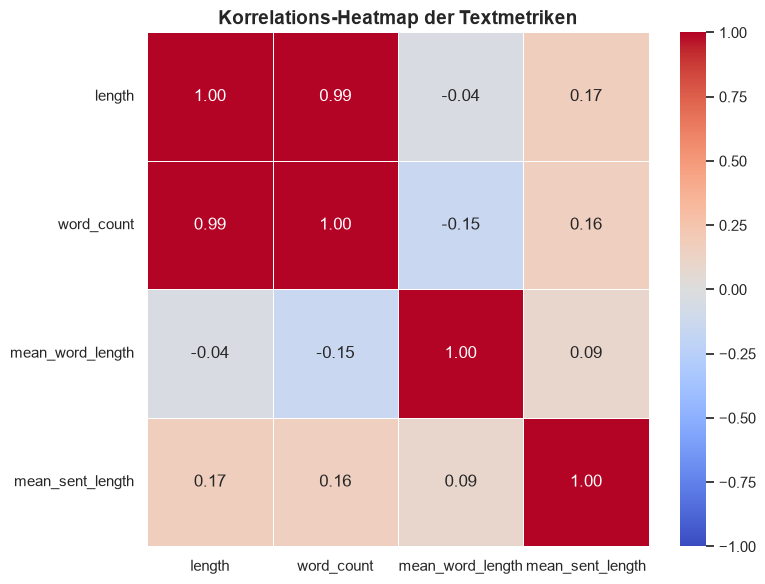

In [324]:
# 2. Korrelations-Heatmap für alle Textmetriken
text_metrics = ['length', 'word_count', 'mean_word_length', 'mean_sent_length']
corr_matrix = data[text_metrics].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    fmt='.2f',
    linewidths=0.5,
)
plt.title(
    'Korrelations-Heatmap der Textmetriken', fontsize=14, fontweight='bold'
)
plt.tight_layout()
plt.show()